 ***Data Analytics Internship Tasks***

**Import Libraries**

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

 **TASK 1 — Web Scraping with *BeautifulSoup***

Step 1.1 — Send a request to the web page

In [2]:
# Target page: Meta Platforms news on Yahoo Finance
url = "https://finance.yahoo.com/quote/META/news"

# A User-Agent header makes our request look like a real browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=15)
print("Status code:", response.status_code)

Status code: 404


Step 1.2 — Parse the HTML and extract headlines

In [3]:
headlines = []

if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")

  # looping through them and grabbing the visible text.
    for tag in soup.find_all(["h3", "h2"]):
        text = tag.get_text(strip=True)
        if text and len(text) > 25:
            headlines.append(text)

    # Remove duplicates while keeping order
    headlines = list(dict.fromkeys(headlines))

print(f"Scraped {len(headlines)} headlines")
for h in headlines[:5]:
    print("-", h)

Scraped 0 headlines


Step 1.3 — Backup sample data (used only if scraping returns nothing)

In [4]:
# Website layouts change often. If the live scrape returns few/no rows,
# we fall back to this sample so the analysis below always runs.
if len(headlines) < 5:
    print("Live scrape returned little data — using backup sample dataset.")
    headlines = [
        "Meta announces new AI features across its apps",
        "Meta stock rises after strong quarterly earnings report",
        "Meta faces regulatory scrutiny over data privacy concerns",
        "Meta invests billions in metaverse and Reality Labs division",
        "Analysts upgrade Meta stock to a strong buy rating",
        "Meta cuts costs as it focuses on efficiency and growth",
        "Meta launches new Threads features to compete with rivals",
        "Meta shares dip amid broader tech market sell-off",
        "Meta expands AI data centers to support new models",
        "Meta beats revenue expectations driven by ad growth",
        "Meta warns of higher spending on AI infrastructure",
        "Meta partners with brands to boost Reels advertising",
        "Meta stock hits new high after positive guidance",
        "Meta to lay off staff in restructuring effort",
        "Meta reports growth in daily active users worldwide",
        "Investors react positively to Meta AI strategy update",
        "Meta announces dividend increase for shareholders",
        "Regulators question Meta over teen safety on platforms",
        "Meta Quest headset sales exceed market expectations",
        "Meta loses ground as advertisers cut budgets",
    ]
print("Total headlines for analysis:", len(headlines))

Live scrape returned little data — using backup sample dataset.
Total headlines for analysis: 20


Step 1.4 — Build the custom dataset (DataFrame) and save to CSV

In [5]:
news_df = pd.DataFrame({
    "headline": headlines
})

# Add a simple length feature (number of words) for later analysis
news_df["word_count"] = news_df["headline"].apply(lambda x: len(x.split()))
news_df["char_count"] = news_df["headline"].apply(len)

# Save our scraped dataset to a CSV file (this is our "custom dataset")
news_df.to_csv("meta_news_headlines.csv", index=False)
print("Saved as meta_news_headlines.csv")
news_df.head()

Saved as meta_news_headlines.csv


,headline,word_count,char_count
0,Meta announces new AI features across its apps,8,46
1,Meta stock rises after strong quarterly earnin...,8,55
2,Meta faces regulatory scrutiny over data priva...,8,57
3,Meta invests billions in metaverse and Reality...,9,60
4,Analysts upgrade Meta stock to a strong buy ra...,9,50


**TASK 2 — Exploratory Data Analysis (EDA)**

Step 2.1 — Structure, data types, and summary

In [6]:
print("Shape (rows, columns):", news_df.shape)
print("\nData types:")
print(news_df.dtypes)
print("\nSummary statistics:")
news_df.describe()

Shape (rows, columns): (20, 3)

Data types:
headline      object
word_count     int64
char_count     int64
dtype: object

Summary statistics:


,word_count,char_count
count,20.000000,20.000000
mean,8.100000,51.300000
std,0.852242,4.105196
min,6.000000,44.000000
25%,8.000000,49.000000
50%,8.000000,51.000000
75%,8.250000,54.000000
max,10.000000,60.000000


Step 2.2 — Data quality check (missing values & duplicates)

In [7]:
print("Missing values per column:")
print(news_df.isnull().sum())
print("\nDuplicate headlines:", news_df.duplicated(subset="headline").sum())

# Drop duplicates/empties if any
news_df = news_df.drop_duplicates(subset="headline").dropna()
print("Rows after cleaning:", len(news_df))

Missing values per column:
headline      0
word_count    0
char_count    0
dtype: int64

Duplicate headlines: 0
Rows after cleaning: 20


Step 2.3 — Most frequent words (pattern detection)

In [8]:
# Combine all headlines, lowercase, and split into words
all_text = " ".join(news_df["headline"]).lower()
words = re.findall(r"[a-z]+", all_text)

# Remove very common stop-words so real topics stand out
stop_words = {"the","a","an","to","of","in","on","for","and","as","at","its",
              "is","it","with","amid","after","over","new","up","meta"}
keywords = [w for w in words if w not in stop_words and len(w) > 2]

word_freq = pd.Series(keywords).value_counts().head(10)
print("Top 10 keywords in META news:")
print(word_freq)

Top 10 keywords in META news:
stock           3
growth          3
features        2
strong          2
data            2
announces       2
expectations    2
off             2
market          2
quarterly       1
Name: count, dtype: int64


Step 2.4 — Simple sentiment tagging (testing a hypothesis)

In [9]:
# Hypothesis: news headlines mix positive and negative tones.
positive_words = ["rises","strong","beats","high","growth","upgrade","buy",
                  "positive","exceed","boost","increase","gains","gain"]
negative_words = ["dip","cut","loses","warns","scrutiny","concerns","sell",
                  "layoff","lay","fall","drop","question","risk"]

def tag_sentiment(text):
    t = text.lower()
    pos = sum(w in t for w in positive_words)
    neg = sum(w in t for w in negative_words)
    if pos > neg: return "Positive"
    if neg > pos: return "Negative"
    return "Neutral"

news_df["sentiment"] = news_df["headline"].apply(tag_sentiment)
print(news_df["sentiment"].value_counts())
news_df.head()

sentiment
Positive    9
Neutral     6
Negative    5
Name: count, dtype: int64


,headline,word_count,char_count,sentiment
0,Meta announces new AI features across its apps,8,46,Neutral
1,Meta stock rises after strong quarterly earnin...,8,55,Positive
2,Meta faces regulatory scrutiny over data priva...,8,57,Negative
3,Meta invests billions in metaverse and Reality...,9,60,Neutral
4,Analysts upgrade Meta stock to a strong buy ra...,9,50,Positive


**TASK 3 — Data Visualization**

Chart 1 — Sentiment distribution (is the news mood positive or negative?)

/tmp/ipykernel_8898/1498219998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=news_df, x="sentiment", order=order, palette="Set1")


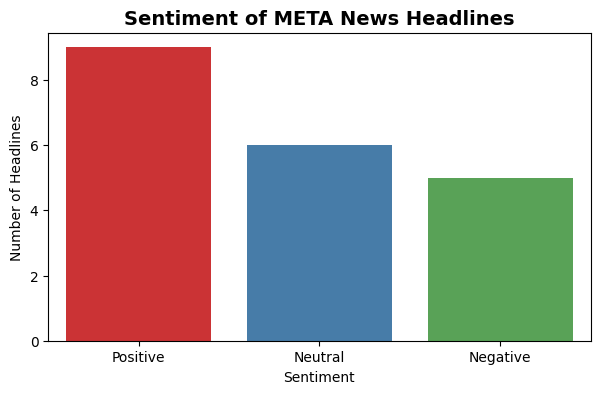

In [19]:
plt.figure(figsize=(7,4))
order = ["Positive","Neutral","Negative"]
sns.countplot(data=news_df, x="sentiment", order=order, palette="Set1")
plt.title("Sentiment of META News Headlines", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Headlines")
plt.show()

Chart 2 — Top keywords in META news

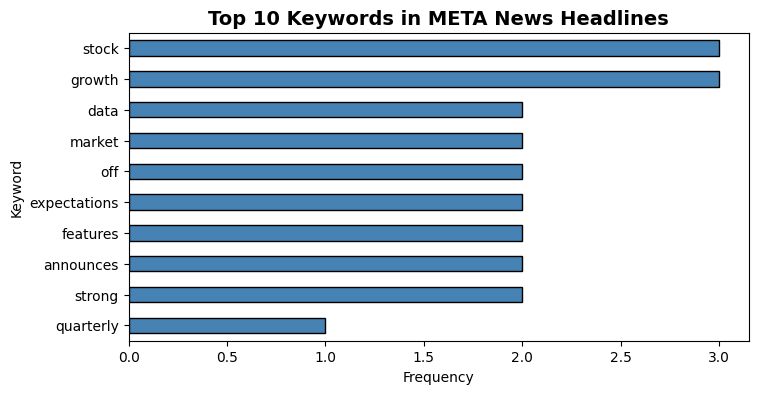

In [11]:
plt.figure(figsize=(8,4))
word_freq.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 10 Keywords in META News Headlines", fontsize=14, fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()

Chart 3 — Distribution of headline length

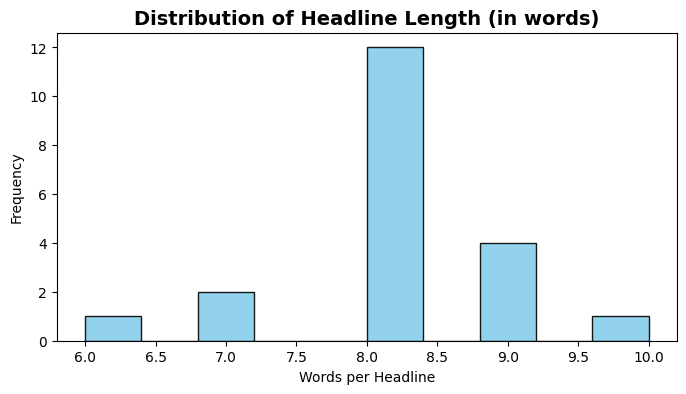

In [12]:
plt.figure(figsize=(8,4))
plt.hist(news_df["word_count"], bins=10, color="skyblue", edgecolor="black", alpha=0.9)
plt.title("Distribution of Headline Length (in words)", fontsize=14, fontweight="bold")
plt.xlabel("Words per Headline")
plt.ylabel("Frequency")
plt.show()

**TASK 4 — Sentiment Analysis (NLP with VADER lexicon)**

In [13]:
!pip install nltk

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon (only needed once)
nltk.download("vader_lexicon")

# Create the analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


 Step 1 — Score each headline
VADER returns a 'compound' score from -1 (very negative) to +1 (very positive)

In [14]:
def vader_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

news_df["compound_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)
news_df["nlp_sentiment"] = news_df["headline"].apply(vader_sentiment)

print(news_df[["headline", "compound_score", "nlp_sentiment"]].head(10))

                                            headline  compound_score  \
0     Meta announces new AI features across its apps          0.0000   
1  Meta stock rises after strong quarterly earnin...          0.5106   
2  Meta faces regulatory scrutiny over data priva...          0.0000   
3  Meta invests billions in metaverse and Reality...          0.0000   
4  Analysts upgrade Meta stock to a strong buy ra...          0.5106   
5  Meta cuts costs as it focuses on efficiency an...          0.4404   
6  Meta launches new Threads features to compete ...          0.0000   
7  Meta shares dip amid broader tech market sell-off          0.2960   
8  Meta expands AI data centers to support new mo...          0.4767   
9  Meta beats revenue expectations driven by ad g...          0.3818   

  nlp_sentiment  
0       Neutral  
1      Positive  
2       Neutral  
3       Neutral  
4      Positive  
5      Positive  
6       Neutral  
7      Positive  
8      Positive  
9      Positive  


Step 3 — Visualize the sentiment distribution

/tmp/ipykernel_8898/2058876207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=news_df, x="nlp_sentiment", order=order, palette="Set1")


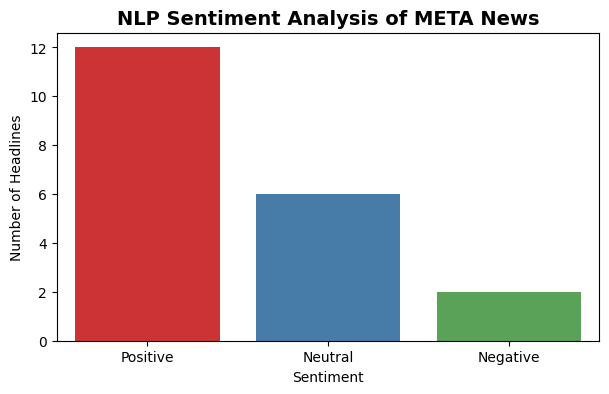

In [17]:
plt.figure(figsize=(7,4))
order = ["Positive", "Neutral", "Negative"]
sns.countplot(data=news_df, x="nlp_sentiment", order=order, palette="Set1")
plt.title("NLP Sentiment Analysis of META News", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Headlines")
plt.show()

Step 4 — Most positive and most negative headlines (insight for decision-making)

In [18]:
print("Most POSITIVE headline:")
print(news_df.loc[news_df["compound_score"].idxmax(), "headline"])

print("\nMost NEGATIVE headline:")
print(news_df.loc[news_df["compound_score"].idxmin(), "headline"])

Most POSITIVE headline:
Meta reports growth in daily active users worldwide

Most NEGATIVE headline:
Meta loses ground as advertisers cut budgets
